# PHYS 449 - Homework 4, Question 2

**Student Name:** Allen Mathew \
**Student ID:** 20964892 \
**Due Date:** Thursday, October 2, 3:00pm 

*ChatGPT was used to help generate the code*
- - -


2. Train a one-hidden-layer feedforward neural network to classify the MNIST handwritten digits dataset. Your input layer should have 784 neurons, and the output layer should have 10 neurons. Begin with 128 hidden neurons, a sigmoid activation function, and a mean-squared error cost function. Use a simple stochastic gradient descent optimizer with a learning rate $\eta = 0.01$, and mini-batches of size 128, to begin. Use the standard training and test sets provided with the MNIST dataset.

In [ ]:
import math, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cpu


In [ ]:
# Downloads on first run.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset_full = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Split off a small validation set from training for monitoring
val_ratio = 0.1
n_train = int((1.0 - val_ratio) * len(train_dataset_full))
n_val = len(train_dataset_full) - n_train
train_dataset, val_dataset = random_split(
    train_dataset_full,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)} | Test size: {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.55MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.38MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 7.93MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]

Train size: 54000 | Val size: 6000 | Test size: 10000


In [ ]:
class OneHiddenMLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=128, output_size=10,
                 hidden_activation='sigmoid', output_activation=None):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.hidden_activation = hidden_activation
        self.output_activation = output_activation  # 'sigmoid' for MSE experiments; None for CE
        
    def forward(self, x):
        # x: (N, 1, 28, 28)
        x = x.view(x.size(0), -1)  # flatten -> (N, 784)
        if self.hidden_activation == 'sigmoid':
            x = torch.sigmoid(self.fc1(x))
        elif self.hidden_activation == 'relu':
            x = F.relu(self.fc1(x))
        else:
            raise ValueError("Unsupported hidden_activation. Use 'sigmoid' or 'relu'.")
        
        x = self.fc2(x)  # logits
        if self.output_activation == 'sigmoid':
            # For MSE with one-hot targets we squash outputs into [0,1]
            x = torch.sigmoid(x)
        return x

In [ ]:
def one_hot(labels, num_classes=10):
    y = torch.zeros((labels.size(0), num_classes), device=labels.device)
    y.scatter_(1, labels.view(-1,1), 1.0)
    return y

def make_optimizer(name, params, lr):
    name = name.lower()
    if name == 'sgd':
        return torch.optim.SGD(params, lr=lr)
    if name == 'adam':
        return torch.optim.Adam(params, lr=lr)
    raise ValueError("Unsupported optimizer. Use 'sgd' or 'adam'.")

def train_epoch(model, loader, optimizer, loss_type='mse'):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)  # logits if CE; squashed if MSE
        
        if loss_type == 'mse':
            y_onehot = one_hot(yb, num_classes=10)
            loss = F.mse_loss(out, y_onehot)
        elif loss_type == 'ce':
            loss = F.cross_entropy(out, yb)
        else:
            raise ValueError("loss_type must be 'mse' or 'ce'")
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        total_correct += (torch.argmax(out, dim=1) == yb).sum().item()
        total_count += xb.size(0)
    return total_loss / total_count, total_correct / total_count

@torch.no_grad()
def evaluate(model, loader, loss_type='mse'):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        if loss_type == 'mse':
            y_onehot = one_hot(yb, num_classes=10)
            loss = F.mse_loss(out, y_onehot)
        else:
            loss = F.cross_entropy(out, yb)
        total_loss += loss.item() * xb.size(0)
        total_correct += (torch.argmax(out, dim=1) == yb).sum().item()
        total_count += xb.size(0)
    return total_loss / total_count, total_correct / total_count

def run_experiment(
    hidden_size=128,
    hidden_activation='sigmoid',
    output_activation='sigmoid',  # 'sigmoid' for MSE; None for CE
    loss_type='mse',
    optimizer_name='sgd',
    lr=0.01,
    batch_size=128,
    epochs=20,
    verbose=True
):
    # Dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    
    # Model & optimizer
    model = OneHiddenMLP(hidden_size=hidden_size, hidden_activation=hidden_activation, output_activation=output_activation).to(device)
    opt = make_optimizer(optimizer_name, model.parameters(), lr)
    
    train_acc_hist, val_acc_hist = [], []
    train_loss_hist, val_loss_hist = [], []
    
    for ep in range(1, epochs+1):
        tr_loss, tr_acc = train_epoch(model, train_loader, opt, loss_type=loss_type)
        va_loss, va_acc = evaluate(model, val_loader, loss_type=loss_type)
        train_acc_hist.append(tr_acc); val_acc_hist.append(va_acc)
        train_loss_hist.append(tr_loss); val_loss_hist.append(va_loss)
        if verbose:
            print(f"Epoch {ep:02d}/{epochs} | Train Loss {tr_loss:.4f} | Train Acc {tr_acc:.4f} | Val Acc {va_acc:.4f}")
    
    # Final test accuracy
    test_loss, test_acc = evaluate(model, test_loader, loss_type=loss_type)
    print(f"\nTest Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")
    
    # Accuracy vs Epoch plot (one plot, no custom colors)
    plt.figure()
    plt.plot(range(1, epochs+1), train_acc_hist, label='Train Acc')
    plt.plot(range(1, epochs+1), val_acc_hist, label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Epoch')
    plt.legend()
    plt.show()
    
    return {
        'model': model,
        'test_acc': test_acc,
        'hist': {
            'train_acc': train_acc_hist,
            'val_acc': val_acc_hist,
            'train_loss': train_loss_hist,
            'val_loss': val_loss_hist
        }
    }

(a) Plot the accuracy of your network during training as a function of epoch number. Report the value of the accuracy on the test set after training. Discuss.

C:\Users\Allen\AppData\Roaming\Python\Python312\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01/20 | Train Loss 0.1357 | Train Acc 0.1754 | Val Acc 0.2683
Epoch 02/20 | Train Loss 0.0929 | Train Acc 0.3190 | Val Acc 0.3563
Epoch 03/20 | Train Loss 0.0894 | Train Acc 0.3727 | Val Acc 0.3870
Epoch 04/20 | Train Loss 0.0883 | Train Acc 0.3879 | Val Acc 0.4020
Epoch 05/20 | Train Loss 0.0876 | Train Acc 0.4039 | Val Acc 0.4070
Epoch 06/20 | Train Loss 0.0871 | Train Acc 0.4129 | Val Acc 0.4088
Epoch 07/20 | Train Loss 0.0866 | Train Acc 0.4168 | Val Acc 0.4155
Epoch 08/20 | Train Loss 0.0860 | Train Acc 0.4225 | Val Acc 0.4220
Epoch 09/20 | Train Loss 0.0855 | Train Acc 0.4318 | Val Acc 0.4322
Epoch 10/20 | Train Loss 0.0849 | Train Acc 0.4389 | Val Acc 0.4402
Epoch 11/20 | Train Loss 0.0842 | Train Acc 0.4474 | Val Acc 0.4497
Epoch 12/20 | Train Loss 0.0836 | Train Acc 0.4556 | Val Acc 0.4592
Epoch 13/20 | Train Loss 0.0828 | Train Acc 0.4646 | Val Acc 0.4685
Epoch 14/20 | Train Loss 0.0821 | Train Acc 0.4761 | Val Acc 0.4792
Epoch 15/20 | Train Loss 0.0813 | Train Acc 0.48

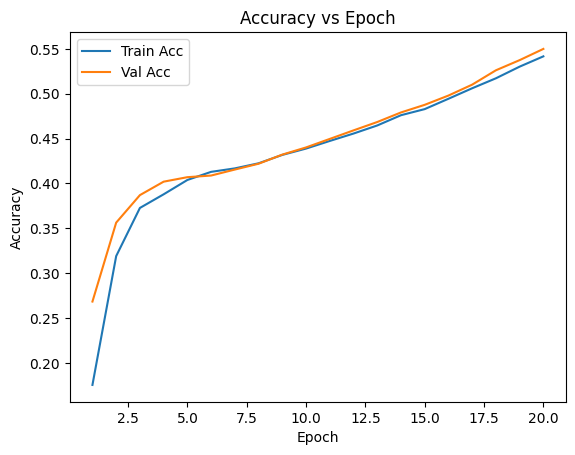

Part (a) — Test Accuracy: 0.5526


In [ ]:
results_a = run_experiment(
    hidden_size=128,
    hidden_activation='sigmoid',
    output_activation='sigmoid',  # because using MSE with one-hot targets
    loss_type='mse',
    optimizer_name='sgd',
    lr=0.01,
    batch_size=128,
    epochs=20,
    verbose=True
)
print("Part (a) — Test Accuracy:", results_a['test_acc'])

As we can see, we get an accuracy of 55.26% on the test set after training. Based on the graph, we see a slow but steady increase in accuracy per epoch. However training with SGD and MSE results in pretty low accuracy even after 20 epochs. We can also notice that the training and validation curves rise about the same and very close to eachother. This can be a sign of underfitting because the model fails to really generalize the data, especially since their accuracy numbers are so low.

(b) Switch to the Adam optimizer with a learning rate of 0.001. Repeat the plots in part (a).

Epoch 01/20 | Train Loss 0.0429 | Train Acc 0.8071 | Val Acc 0.9057
Epoch 02/20 | Train Loss 0.0156 | Train Acc 0.9200 | Val Acc 0.9225
Epoch 03/20 | Train Loss 0.0117 | Train Acc 0.9361 | Val Acc 0.9335
Epoch 04/20 | Train Loss 0.0098 | Train Acc 0.9467 | Val Acc 0.9397
Epoch 05/20 | Train Loss 0.0084 | Train Acc 0.9541 | Val Acc 0.9462
Epoch 06/20 | Train Loss 0.0075 | Train Acc 0.9594 | Val Acc 0.9522
Epoch 07/20 | Train Loss 0.0067 | Train Acc 0.9641 | Val Acc 0.9560
Epoch 08/20 | Train Loss 0.0060 | Train Acc 0.9685 | Val Acc 0.9567
Epoch 09/20 | Train Loss 0.0054 | Train Acc 0.9721 | Val Acc 0.9577
Epoch 10/20 | Train Loss 0.0050 | Train Acc 0.9748 | Val Acc 0.9585
Epoch 11/20 | Train Loss 0.0045 | Train Acc 0.9779 | Val Acc 0.9613
Epoch 12/20 | Train Loss 0.0041 | Train Acc 0.9804 | Val Acc 0.9630
Epoch 13/20 | Train Loss 0.0038 | Train Acc 0.9821 | Val Acc 0.9645
Epoch 14/20 | Train Loss 0.0034 | Train Acc 0.9834 | Val Acc 0.9642
Epoch 15/20 | Train Loss 0.0032 | Train Acc 0.98

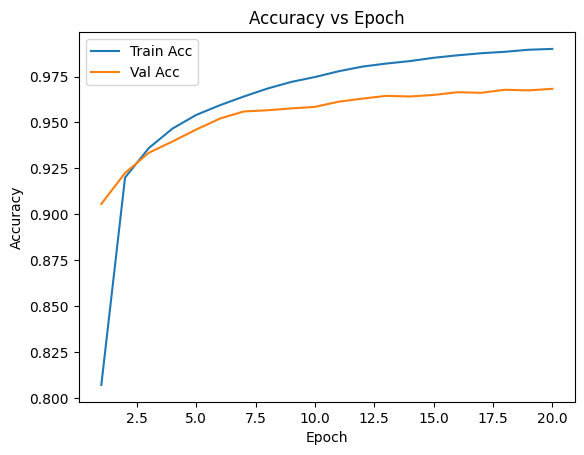

Part (b) — Test Accuracy: 0.9721


In [ ]:
results_b = run_experiment(
    hidden_size=128,
    hidden_activation='sigmoid',
    output_activation='sigmoid',
    loss_type='mse',
    optimizer_name='adam',
    lr=0.001,
    batch_size=128,
    epochs=20,
    verbose=True
)
print("Part (b) — Test Accuracy:", results_b['test_acc'])

Switching to the Adam optimizer with a learning rate of 0.001 greatly improved the accuracy on the test set after training. We get an accuracy of 97.21%. Looking at the graph, but the trianing and validation accuracy rise quickly at first and then slows down. We can also see that the training data accuracy is marginally higher than the validation accuracy. This could be a sign of slight overfitting, the model is slightly more accurate with the training data than the unseen validation data.

(c) Continue by switching to a ReLU activation function, and repeat part (a).

Epoch 01/20 | Train Loss 0.0241 | Train Acc 0.8583 | Val Acc 0.9277
Epoch 02/20 | Train Loss 0.0101 | Train Acc 0.9440 | Val Acc 0.9417
Epoch 03/20 | Train Loss 0.0076 | Train Acc 0.9577 | Val Acc 0.9518
Epoch 04/20 | Train Loss 0.0062 | Train Acc 0.9664 | Val Acc 0.9608
Epoch 05/20 | Train Loss 0.0054 | Train Acc 0.9710 | Val Acc 0.9622
Epoch 06/20 | Train Loss 0.0046 | Train Acc 0.9754 | Val Acc 0.9687
Epoch 07/20 | Train Loss 0.0042 | Train Acc 0.9782 | Val Acc 0.9692
Epoch 08/20 | Train Loss 0.0038 | Train Acc 0.9809 | Val Acc 0.9725
Epoch 09/20 | Train Loss 0.0034 | Train Acc 0.9830 | Val Acc 0.9723
Epoch 10/20 | Train Loss 0.0031 | Train Acc 0.9844 | Val Acc 0.9748
Epoch 11/20 | Train Loss 0.0029 | Train Acc 0.9854 | Val Acc 0.9745
Epoch 12/20 | Train Loss 0.0026 | Train Acc 0.9870 | Val Acc 0.9745
Epoch 13/20 | Train Loss 0.0025 | Train Acc 0.9878 | Val Acc 0.9760
Epoch 14/20 | Train Loss 0.0022 | Train Acc 0.9889 | Val Acc 0.9752
Epoch 15/20 | Train Loss 0.0021 | Train Acc 0.98

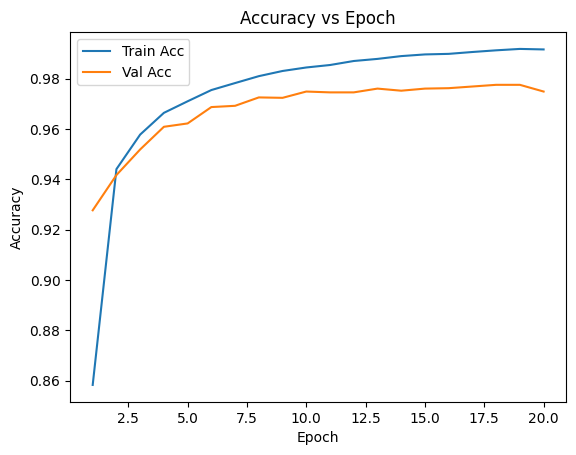

Part (c) — Test Accuracy: 0.9762


In [ ]:
results_c = run_experiment(
    hidden_size=128,
    hidden_activation='relu',    # switch hidden activation to ReLU
    output_activation='sigmoid', # still using MSE with one-hot targets
    loss_type='mse',
    optimizer_name='adam',
    lr=0.001,
    batch_size=128,
    epochs=20,
    verbose=True
)
print("Part (c) — Test Accuracy:", results_c['test_acc'])

Switching to a ReLU activation function causes our test accuracy to marginally increase to 97.62%. The gap between the training and validation accuracy is very small, meaning the model does a good job generalizing the data.

(d) Continue by switching to a cross-entropy cost function, and repeat part (a).

Epoch 01/20 | Train Loss 0.3205 | Train Acc 0.9081 | Val Acc 0.9448
Epoch 02/20 | Train Loss 0.1417 | Train Acc 0.9591 | Val Acc 0.9598
Epoch 03/20 | Train Loss 0.0978 | Train Acc 0.9707 | Val Acc 0.9688
Epoch 04/20 | Train Loss 0.0722 | Train Acc 0.9789 | Val Acc 0.9672
Epoch 05/20 | Train Loss 0.0555 | Train Acc 0.9836 | Val Acc 0.9722
Epoch 06/20 | Train Loss 0.0469 | Train Acc 0.9858 | Val Acc 0.9752
Epoch 07/20 | Train Loss 0.0389 | Train Acc 0.9880 | Val Acc 0.9743
Epoch 08/20 | Train Loss 0.0309 | Train Acc 0.9906 | Val Acc 0.9745
Epoch 09/20 | Train Loss 0.0255 | Train Acc 0.9924 | Val Acc 0.9730
Epoch 10/20 | Train Loss 0.0211 | Train Acc 0.9939 | Val Acc 0.9757
Epoch 11/20 | Train Loss 0.0161 | Train Acc 0.9955 | Val Acc 0.9757
Epoch 12/20 | Train Loss 0.0135 | Train Acc 0.9963 | Val Acc 0.9755
Epoch 13/20 | Train Loss 0.0115 | Train Acc 0.9969 | Val Acc 0.9727
Epoch 14/20 | Train Loss 0.0108 | Train Acc 0.9970 | Val Acc 0.9745
Epoch 15/20 | Train Loss 0.0101 | Train Acc 0.99

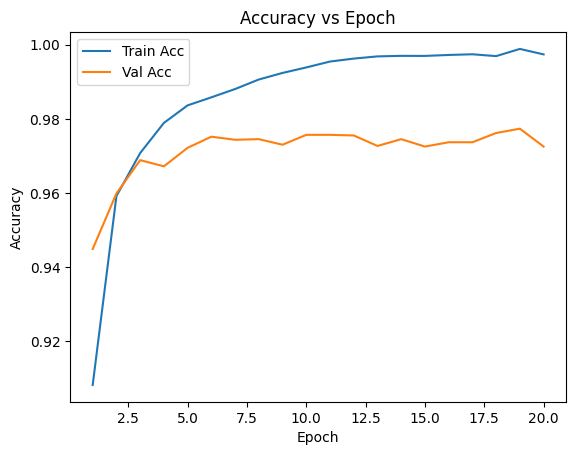

Part (d) — Test Accuracy: 0.9736


In [ ]:
# CrossEntropy: output_activation must be None (raw logits); targets are class indices
results_d = run_experiment(
    hidden_size=128,
    hidden_activation='relu',
    output_activation=None,  # IMPORTANT for CE
    loss_type='ce',
    optimizer_name='adam',
    lr=0.001,
    batch_size=128,
    epochs=20,
    verbose=True
)
print("Part (d) — Test Accuracy:", results_d['test_acc'])

Switching to a cross-entropy cost function with Adam and ReLU gives us a test accuracy slightly lower than the Adam + ReLU + MSE model, but still higher than the Adam + Sigmoid + MSE model. The test accuracy for this cross-entropy cost function model is 97.36%. One thing that we can notice is that there is that the validation accuracy is pretty inconsistent compared to the previous models', the line is much more jagged. I would assume this is becasue of the use of a different cost function.

(e) Finally, explore as systematically as possible the hyperperameter space of your network, including number of hidden neurons, learning rate, mini-batch size, and number of epochs. Report the best accuracy you can achieve on the test set, and which hyperparameters you used to achieve it.


Config: {'hidden_size': 64, 'hidden_activation': 'relu', 'loss_type': 'ce', 'optimizer_name': 'adam', 'lr': 0.001, 'batch_size': 64, 'epochs': 15}

Test Loss: 0.1092 | Test Accuracy: 0.9732


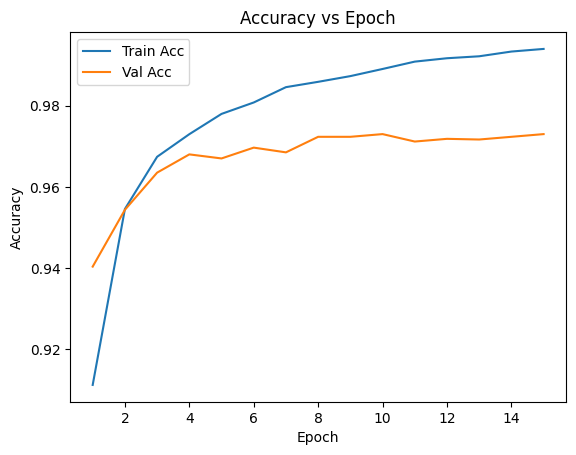

Test Acc: 0.9732

Config: {'hidden_size': 64, 'hidden_activation': 'relu', 'loss_type': 'ce', 'optimizer_name': 'adam', 'lr': 0.001, 'batch_size': 128, 'epochs': 15}

Test Loss: 0.0995 | Test Accuracy: 0.9730


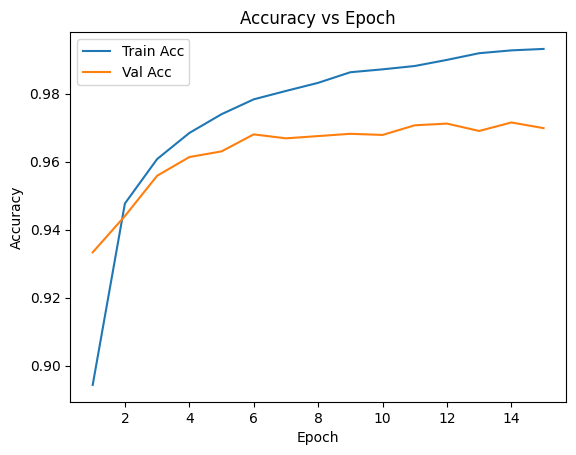

Test Acc: 0.9730

Config: {'hidden_size': 64, 'hidden_activation': 'relu', 'loss_type': 'ce', 'optimizer_name': 'adam', 'lr': 0.0005, 'batch_size': 64, 'epochs': 15}

Test Loss: 0.0886 | Test Accuracy: 0.9755


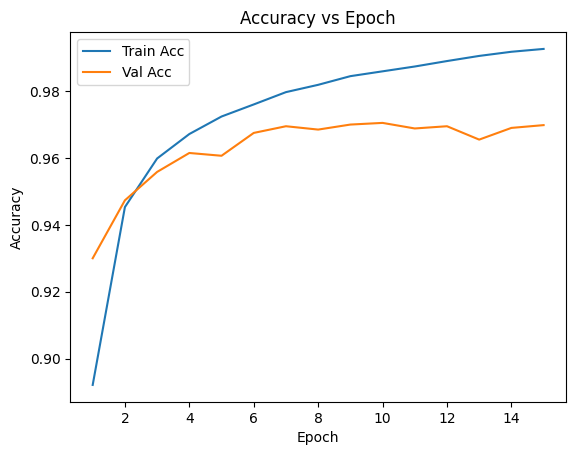

Test Acc: 0.9755

Config: {'hidden_size': 64, 'hidden_activation': 'relu', 'loss_type': 'ce', 'optimizer_name': 'adam', 'lr': 0.0005, 'batch_size': 128, 'epochs': 15}

Test Loss: 0.0803 | Test Accuracy: 0.9764


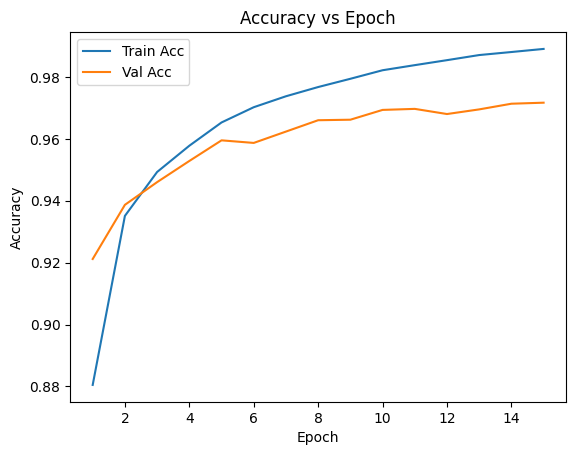

Test Acc: 0.9764

Config: {'hidden_size': 128, 'hidden_activation': 'relu', 'loss_type': 'ce', 'optimizer_name': 'adam', 'lr': 0.001, 'batch_size': 64, 'epochs': 15}

Test Loss: 0.1065 | Test Accuracy: 0.9765


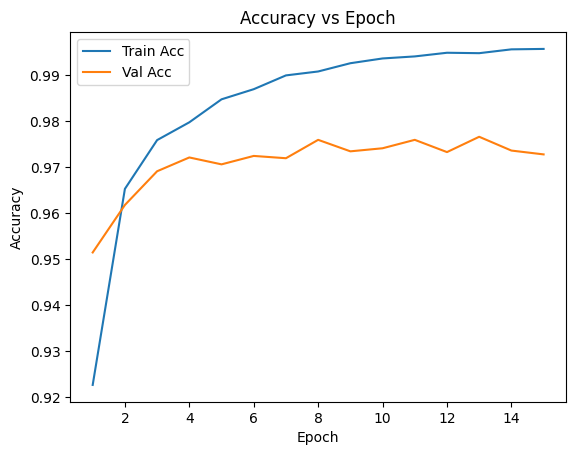

Test Acc: 0.9765

Config: {'hidden_size': 128, 'hidden_activation': 'relu', 'loss_type': 'ce', 'optimizer_name': 'adam', 'lr': 0.001, 'batch_size': 128, 'epochs': 15}

Test Loss: 0.0976 | Test Accuracy: 0.9762


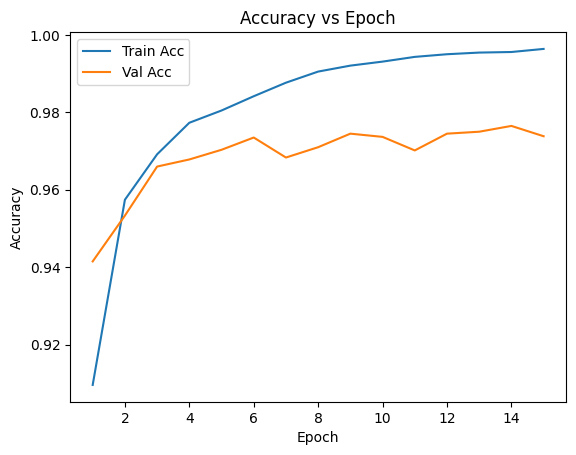

Test Acc: 0.9762

Config: {'hidden_size': 128, 'hidden_activation': 'relu', 'loss_type': 'ce', 'optimizer_name': 'adam', 'lr': 0.0005, 'batch_size': 64, 'epochs': 15}

Test Loss: 0.0795 | Test Accuracy: 0.9788


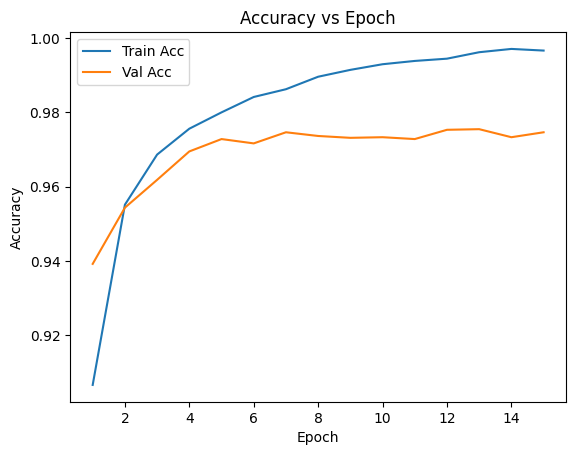

Test Acc: 0.9788

Config: {'hidden_size': 128, 'hidden_activation': 'relu', 'loss_type': 'ce', 'optimizer_name': 'adam', 'lr': 0.0005, 'batch_size': 128, 'epochs': 15}

Test Loss: 0.0691 | Test Accuracy: 0.9805


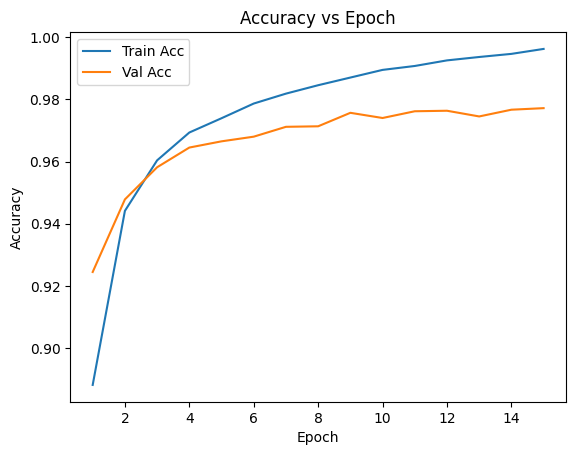

Test Acc: 0.9805

Config: {'hidden_size': 256, 'hidden_activation': 'relu', 'loss_type': 'ce', 'optimizer_name': 'adam', 'lr': 0.001, 'batch_size': 64, 'epochs': 15}

Test Loss: 0.0969 | Test Accuracy: 0.9794


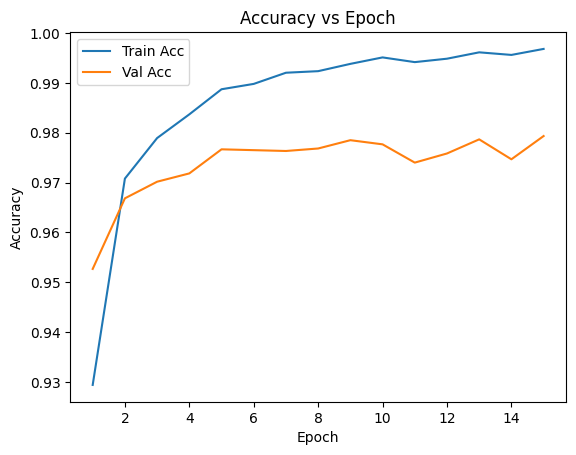

Test Acc: 0.9794

Config: {'hidden_size': 256, 'hidden_activation': 'relu', 'loss_type': 'ce', 'optimizer_name': 'adam', 'lr': 0.001, 'batch_size': 128, 'epochs': 15}

Test Loss: 0.1020 | Test Accuracy: 0.9750


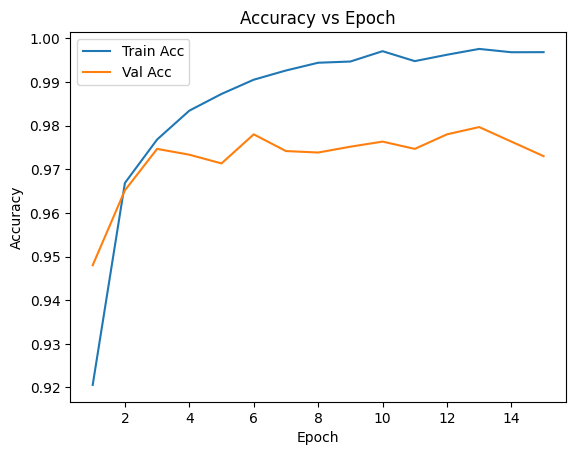

Test Acc: 0.9750

Config: {'hidden_size': 256, 'hidden_activation': 'relu', 'loss_type': 'ce', 'optimizer_name': 'adam', 'lr': 0.0005, 'batch_size': 64, 'epochs': 15}

Test Loss: 0.0944 | Test Accuracy: 0.9774


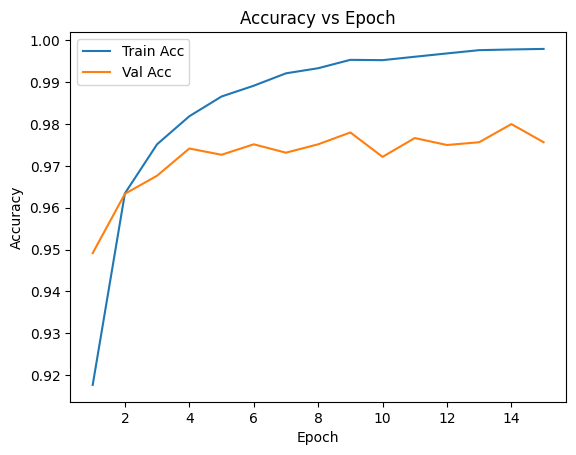

Test Acc: 0.9774

Config: {'hidden_size': 256, 'hidden_activation': 'relu', 'loss_type': 'ce', 'optimizer_name': 'adam', 'lr': 0.0005, 'batch_size': 128, 'epochs': 15}

Test Loss: 0.0673 | Test Accuracy: 0.9796


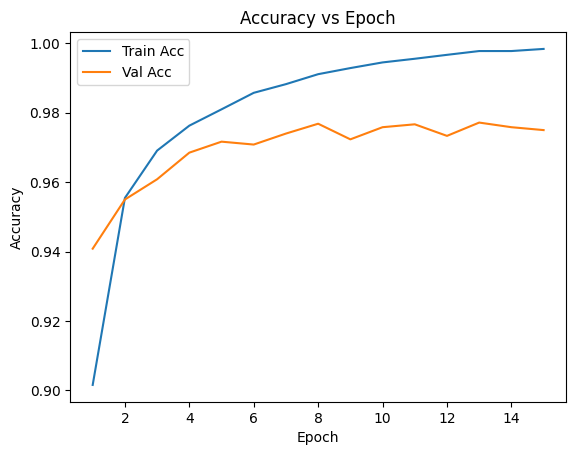

Test Acc: 0.9796

Grid search finished in 41.4 min (wall clock). Top results:
 1) Acc=0.9805 | {'hidden_size': 128, 'hidden_activation': 'relu', 'loss_type': 'ce', 'optimizer_name': 'adam', 'lr': 0.0005, 'batch_size': 128, 'epochs': 15}
 2) Acc=0.9796 | {'hidden_size': 256, 'hidden_activation': 'relu', 'loss_type': 'ce', 'optimizer_name': 'adam', 'lr': 0.0005, 'batch_size': 128, 'epochs': 15}
 3) Acc=0.9794 | {'hidden_size': 256, 'hidden_activation': 'relu', 'loss_type': 'ce', 'optimizer_name': 'adam', 'lr': 0.001, 'batch_size': 64, 'epochs': 15}
 4) Acc=0.9788 | {'hidden_size': 128, 'hidden_activation': 'relu', 'loss_type': 'ce', 'optimizer_name': 'adam', 'lr': 0.0005, 'batch_size': 64, 'epochs': 15}
 5) Acc=0.9774 | {'hidden_size': 256, 'hidden_activation': 'relu', 'loss_type': 'ce', 'optimizer_name': 'adam', 'lr': 0.0005, 'batch_size': 64, 'epochs': 15}


In [ ]:
from itertools import product

search_space = {
    'hidden_size': [64, 128, 256],
    'hidden_activation': ['relu'],   # ReLU tends to perform better
    'loss_type': ['ce'],             # Cross-Entropy for classification
    'optimizer_name': ['adam'],
    'lr': [0.001, 0.0005],
    'batch_size': [64, 128],
    'epochs': [15]                   # modest for speed
}

def grid_params(space):
    keys = list(space.keys())
    for values in product(*[space[k] for k in keys]):
        yield dict(zip(keys, values))

results = []
start = time.time()
for cfg in grid_params(search_space):
    print("\nConfig:", cfg)
    res = run_experiment(
        hidden_size=cfg['hidden_size'],
        hidden_activation=cfg['hidden_activation'],
        output_activation=None,   # CE -> raw logits
        loss_type=cfg['loss_type'],
        optimizer_name=cfg['optimizer_name'],
        lr=cfg['lr'],
        batch_size=cfg['batch_size'],
        epochs=cfg['epochs'],
        verbose=False
    )
    results.append((cfg, res['test_acc']))
    print(f"Test Acc: {res['test_acc']:.4f}")
    
elapsed = time.time() - start
print(f"\nGrid search finished in {elapsed/60:.1f} min (wall clock). Top results:")
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)
for i, (cfg, acc) in enumerate(results_sorted[:5], 1):
    print(f"{i:>2}) Acc={acc:.4f} | {cfg}")

To explore hyperparameter space, we explore variations in the number of hidden neurons, the learning rate, mini-batch size, and the number of epochs. Essentially we are performing a grid search over these parameters to find the configuration with the highest accuracy. The highest accuracy we were able to achieve was 98.05% with the configuration of {'hidden_size': 128, 'hidden_activation': 'relu', 'loss_type': 'ce', 'optimizer_name': 'adam', 'lr': 0.0005, 'batch_size': 128, 'epochs': 15}. Exploring hyperparameter space like this really shows how finetuning our moedel can significantly outperform the baseline from part (a).